<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Adam Glos and Özlem Salehi Köken
        </td>        
</tr></table>

$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $


# Grover's Algorithm revisited

Grover's Search is one of the well-known quantum algorithms. Given an oracle which marks some of the elements in the search space, Grover's Algrorithm outputs the marked elements with high probability. This notebook only serves as a recap for Grover's Search. We refer to Bronze for the actual explanation of the algorithm.

In this notebook, we will provide an alternative implementation, that does not use phase-kickback to flip the phase of the marked element and inside the Diffusion operator, but instead one that uses $Z$-gate.

The quantum circuit for the algorithm takes the form:

<img src="../images/grover.png" width="50%" align="center">

Oracle is responsible for marking the elements, while Grover diffusion operator amplifies the probability of measuring the marked elements. They are applied interchangeably for $\lfloor \frac{\pi}{4}\sqrt{\frac{N}{k}} \rfloor$ times, where $N$ is the size of the searh space, and $k$ is the number of marked elements.

## A simple problem

We will assume that the search space conists of $N$ elements $\{0,1,2,\dots,N-1 \}$ and that $N-1$ is the marked element, where $N = 2^n$. 

Here is the general structure of the implementation for Grover's search algorithm. In this notebook, we will complete the functions `initialize`, `oracle` and `diffusion`. We will use $n$ qubits (qubits numbered 0 to $n-1$) to represent the search space and 1 auxilliary qubit (qubit $n$).

In [ ]:
from qiskit import QuantumCircuit
from math import sqrt, pi, log2

def grover(N):
    n = int(log2(N))
    num_iterations = int(sqrt(N) * (pi / 4))

    qc = QuantumCircuit(n+1)
    initialize(qc, n)
    for i in range(num_iterations):
        oracle(qc, n)
        diffusion(qc, n)
    qc.measure(range(n), range(n))
    return qc

## Initialization 

The Grover's search starts with creating an equal superposition on all qubits. We start with implementing the initialization step.

### Task 1 
Write a function named `initialize` that takes as input a `QuantumCircuit` object and the number of qubits `n` that represents the search space. Create equal superposition of all $n$ qubits.

In [ ]:
#Your code here


[click for our solution](01_grover_algorithm_revisited_solutions.ipynb#task1)

## A simple oracle

Here we will design a simple oracle, which marks the state $\ket{1111}$. Here marking means to changing the sign of the amplitude of the state $\ket{1111}$, while leaving the other states unchanged. 

To mark the state, we will implement a multi-controlled NOT gate that applies a NOT gate to the auxilliary qubit if all the control qubits are in state $\ket{1}$ and then apply a $Z$ gate to the auxilliary qubit. Then we will apply the multi-controlled NOT gate again to set back to auxilliary qubit to its original state.


In qiskit, the multi-controlled NOT gate can be implemented as follows:

`qc.mcx([control_qubits], target_qubit)`

Now we are ready to implement an oracle that flips the sign of the state $\ket{1111}$.

### Task 2

Create a function named `oracle` that takes as input a `QuantumCircuit` object, and `n` the number of qubits that represent the search space. Your oracle should mark the state $|1\rangle^{\otimes n}$, by first applying a multi-controlled gate and then applying a $Z$ gate on the auxilliary qubit. You can use the given code to test your function.

In [ ]:
def oracle(qc, n):

# Your code here


In [ ]:
from qiskit.circuit.library import MCXGate
from qiskit import QuantumRegister, QuantumCircuit

n = 4
qc = QuantumCircuit(n+1)
oracle(qc, n)
qc.draw()

[click for our solution](01_grover_algorithm_revisited_solutions.ipynb#task2)

## The Grover's diffusion operator

The Grover's diffusion (inversion) operator plays a vital role in the algorithm, as it amplifies the amplitude(s) of the marked element(s) if applied for correct number of times. It can be presented by the following unitary matrix:

$$
I - 2
\begin{pmatrix}
\frac{1}{N} & \cdots & \frac{1}{N} \\
\vdots & \ddots & \vdots \\
\frac{1}{N} & \cdots & \frac{1}{N}
\end{pmatrix}
$$

where $N$ is the dimension of the matrix. The implementation of this operator is known. Here is an example circuit given for four qubits $(N = 16)$.

<img src="..\images\grover_diffusion_operator.png" width="40%" align="center">

In general, one can apply Hadamard and $NOT$ gates to each qubit, and then use a multi-controlled $Z$ gate followed by the same $NOT$ and Hadamard gates. 

Please check the end of the notebook to read about why those gates are used to implement the diffusion operator.

Now, we need to learn how implement a multi-controlled $Z$ gate. We will use the `control` function that creates the controlled version of the gates. First we will see how we can use `Gate` objects in Qiskit.





In Qiskit, all the gates can be imported from `qiskit.circuit.library` and then appended to circuits as follows. For instance here we import various gates and append to our circuit.

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import HGate, ZGate, XGate, CXGate, MCXGate

qc = QuantumCircuit(4)
qc.append(HGate(), [0]) #HGate() creates a Hadamard gate, we provide the qubit index as a list, append method adds the gate to the circuit
qc.append(ZGate(), [1])
qc.append(XGate(), [2])


Once can check the corresponding matrices of each gate using `to_matrix()` function.

In [2]:
XGate().to_matrix()

array([[0.+0.j, 1.+0.j],
       [1.+0.j, 0.+0.j]])

We can provide the number of control qubits as an argument to the `control` function. The default number of control qubits is 1, in case no parameter is provided.

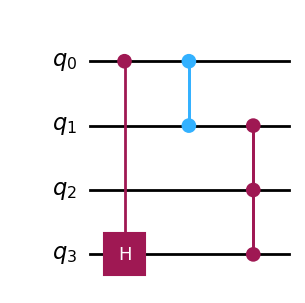

In [16]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import HGate, ZGate, XGate, CXGate

qc = QuantumCircuit(4)
CHGate = HGate().control()  # Create a controlled-Hadamard gate with 1 control qubit (default number of control qubits is 1)
qc.append(CHGate, [0, 3])  # Apply the controlled-Hadamard gate to qubits 0 (control) and 3 (target)

CZGate = ZGate().control()  # Create a controlled-Z gate with 1 control qubit
qc.append(CZGate, [0, 1])  # Apply the controlled-Z gate to qubits 0 (control) and 1 (target)
qc.draw(output='mpl')

CZ2Gate = ZGate().control(2)  # Create a controlled-Z gate with 2 control qubits
qc.append(CZ2Gate, [1, 2, 3])  # Apply the controlled-Z gate to qubits 1, 2 (controls) and 3 (target)
qc.draw(output='mpl')


Note that for `CZ` and `CCZ`, the target qubit is not distinguished when displayed. This is because controlled $Z$ operator acts exactly the same independent of the chosen target qubit. This can be easily seen as there is no way to distinguish which qubit is the target and which one is the control when the `CZ` and `CCZ` gates are applied on `11` and `111`.

We can check this by switching the control and target qubits of CZGate and using `UnitarySimulator`.

In [3]:
from qiskit_aer import UnitarySimulator
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZGate

qc = QuantumCircuit(2)
CZGate = ZGate().control()  # Create a controlled-Z gate with 1 control qubit
qc.append(CZGate, [1, 0])  # Apply the controlled-Z gate to qubits 1 (control) and 0 (target)
job = UnitarySimulator().run(qc)
matrix = job.result().get_unitary(decimals=1)

print('Unitary matrix representation of CZ where qubit 1 is control and qubit 0 is target.')
print(matrix) 

qc2 = QuantumCircuit(2)
CZGate_v2 = ZGate().control()  # Create a controlled-Z gate with 1 control qubit
qc2.append(CZGate_v2, [0, 1])  # Apply the controlled-Z gate to qubits 0 (control) and 1 (target)
job = UnitarySimulator().run(qc2)
matrix = job.result().get_unitary(decimals=1)

print('Unitary matrix representation of CZ where qubit 0 is control and qubit 1 is target.')
print(matrix) 

Unitary matrix representation of CZ where qubit 1 is control and qubit 0 is target.
Operator([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
          [-0.+0.j, -0.+0.j, -0.+0.j, -1.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))
Unitary matrix representation of CZ where qubit 0 is control and qubit 1 is target.
Operator([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
          [-0.+0.j, -0.+0.j, -0.+0.j, -1.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


Now we are ready to implement the diffusion operator.

### Task 3 
    
Complete the function named `diffusion`, that takes as input a `QuantumCircuit` object, and `n` the number of qubits that represent the search space. You can use the given code to test your function.

In [ ]:
def diffusion(qc, n):
    #Your code here

In [ ]:
from qiskit.circuit.library import ZGate
from qiskit import QuantumRegister, QuantumCircuit

n = 4
qc = QuantumCircuit(n+1)
diffusion(qc, n)
qc.draw()

[click for our solution](01_grover_algorithm_revisited_solutions.ipynb#task3)

## Grover's Algorithm

Finally, we are ready to implement the Grover's Algorithm. 

Let us consider the Grover's Search for $N=16$. We make an initialization, then apply the oracle (the one we prepared before) and the diffusion operator alternately for $\lfloor \frac{\pi}{4}\sqrt{16} \rfloor = 3$ times. Eventually, the state $|1111\rangle$ should be measured more often than the other basis states. 

### Task 4

Call the `grover` function defined at the beginning of the notebook with $N=16$ to get the quantum circuit for Grover's algorithm. Use `AerSimulator` and simulate the circuit for 1000 times. Before running your circuit, you need to call the `transpile` function from Qiskit, that will decompose the multi-controlled $Z$ gate into gates that can be handled by `AerSimulator`.

`qc_t = transpile(qc, backend=AerSimulator())`

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile

#Your code here


[click for our solution](01_grover_algorithm_revisited_solutions.ipynb#task4)

## Are we done?

We have just implemented the Grover's search algorithm finding a marked element. In this example, we implemented a very simple oracle which required using the knowledge about the element we were searching for.

In the next notebooks, we will implement less trivial oracles and use Grover's Algorithm to help us in finding out the solution of a harder problem.

----

<h2>Why these gates are chosen? (Optional) </h2>

Now let's try to understand why these gates are chosen. Let's recall the diffusion operator:

$$
I - 2
\begin{pmatrix}
\frac{1}{N} & \cdots & \frac{1}{N} \\
\vdots & \ddots & \vdots \\
\frac{1}{N} & \cdots & \frac{1}{N}
\end{pmatrix}
$$

Recall that the diffusion operator can be expressed as $D=2\ket{u}\bra{u}-I$ where $\ket{u}=H^{\otimes n}\ket{0^n}$ is the equal superposition vector. We will simply denote $\ket{0^n}$ by $\ket{\mathbf{0}}$. 


Instead of $D$, we will implement $-D$. Since the two operators differ by a negative sign, they yield the same observation probabilities. 

For instance, if $D \ket{\psi} = \ket{\phi}$, then $-D \ket{\psi} = -\ket{\phi}$ and the states $\ket{\phi}$ and $-\ket{\phi}$ have identical observation probabilities.

- To start with let's express $-D$ as follows:

\begin{align*}
-D=-(2\ket{u}\bra{u}-I) = I - 2\ket{u}\bra{u} &= I - 2(H^{\otimes n}\ket{\mathbf{0}}\bra{\mathbf{0}}H^{\otimes n}) \\
&= H^{\otimes n}H^{\otimes n} - 2(H^{\otimes n}\ket{\mathbf{0}}\bra{\mathbf{0}}H^{\otimes n})\\
&=H^{\otimes n} (H^{\otimes n} - 2\ket{\mathbf{0}}\bra{\mathbf{0}}H^{\otimes n}) \\
&=H^{\otimes n} (I - 2\ket{\mathbf{0}}\bra{\mathbf{0}})H^{\otimes n}
\end{align*}

<i>Looking at this expression, we understand why we have $H$ gates at the beginning and at the end</i>

- Now let us look at the effect of applying $I - 2\ket{\mathbf{0}}\bra{\mathbf{0}}$ to any arbitrary state.

$(I - 2\ket{\mathbf{0}}\bra{\mathbf{0}}) \ket{x} = \ket{x} - 2\ket{\mathbf{0}}\braket{\mathbf{0}}{x}.$

If $\ket{x}=\ket{\mathbf{0}}$, since $\braket{\mathbf{0}}{\mathbf{0}}=1$, then $ \ket{x} - 2\ket{\mathbf{0}}\braket{\mathbf{0}}{x} = \ket{\mathbf{0}} - 2\ket{\mathbf{0}}\braket{\mathbf{0}}{\mathbf{0}} =\ket{\mathbf{0}} -2\ket{\mathbf{0}} = - \ket{\mathbf{0}}$.

If $\ket{x}\neq \ket{\mathbf{0}}$, since $\braket{\mathbf{0}}{x}=0$, then $ \ket{x} - 2\ket{\mathbf{0}}\braket{\mathbf{0}}{x} =  \ket{x} - 2\ket{\mathbf{0}}\cdot 0  = \ket{x}$.

Hence, the effect of $I - 2\ket{\mathbf{0}}\bra{\mathbf{0}}$ is flipping the amplitude of the state $\ket{\mathbf{0}}$.

- How to check if the quantum state is equal to $\ket{\bf{0}}$ and flip its amplitude?

If all qubits were in state $\ket{1}$, then we could use a multi-controlled $Z$ gate to flip the amplitude. Instead, we need to apply a multi-controlled $Z$ gate when all qubits are in state state $\ket{0}$.

 <i> That's why we first apply $X$ gates and then apply multi-controlled $Z$ gate. Afterwards, we set the qubits back by applying $X$ gates again (Recall the multiple controlled constructions notebook.). </i>